# 네트워크 침입 탐지 — 독립 딥러닝 Pipeline v12

## 가설

이전 v6~v11 모델, 라우터, 예측값, 모델 가중치와 임계값을 전혀 사용하지 않고 원본 Flow 피처만 학습하는 residual MLP가 Infilteration Recall을 개선할 수 있다.

### 독립성 원칙

- 입력은 `interim/train.parquet`의 원본 40개 Flow 피처만 사용한다.
- Timestamp, unique_id와 이전 버전에서 만든 시간·비율·서비스 피처는 모델 입력에서 제외한다.
- 모델 구조와 가중치는 무작위 초기화한다.
- 데이터 비교의 정확성을 위해 기존 Benchmark와 같은 250,000행 reservoir(seed 42), 클래스별 시간순 80/20 외부 분할만 유지한다.
- 모델 선택은 외부 검증보다 더 이른 내부 시간 검증에서 수행한다.
- Infilteration 임계값은 외부 검증의 앞 절반에서 보정하고 뒤 절반에서 별도로 확인한다.


In [1]:
from pathlib import Path
import importlib.metadata
import os
import sys
import time
import warnings

import duckdb
import matplotlib.pyplot as plt
import mlflow
import mlflow.pyfunc
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn.functional as F
from mlflow.models import infer_signature
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
)
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)

cwd = Path.cwd()
PROJECT_DIR = cwd.parent if cwd.name == "notebooks" else cwd
sys.path.insert(0, str(PROJECT_DIR / "src"))
from deep_ids_model import DeepIDSPreprocessor, DeepIDSPyFuncModel, DeepTabularNet
from mlflow_workflow import (
    CHAMPION_ALIAS,
    PROJECT_EXPERIMENT,
    REGISTERED_MODEL_NAME,
    VALIDATION_COHORT_ID,
    configure_tracking,
    file_sha256,
    hypothesis_run,
    log_dataframe_input,
    register_model_version,
)

HYPOTHESIS_ID = "v12"
HYPOTHESIS = "standalone_raw_flow_residual_mlp"
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
torch.set_num_threads(min(8, os.cpu_count() or 1))

WORK_ROOT = Path("/home/jovyan/work")
DATA_BASE = WORK_ROOT / "datasets"
matches = sorted(DATA_BASE.glob("*/interim/train.parquet"))
if len(matches) != 1:
    raise RuntimeError(f"Expected one raw training parquet, found: {matches}")
TRAIN_PARQUET = matches[0]
TEST_PARQUET = TRAIN_PARQUET.with_name("test.parquet")
cohort_matches = sorted(DATA_BASE.glob("*/processed/train_temporal_v5.parquet"))
if len(cohort_matches) != 1:
    raise RuntimeError(f"Expected one benchmark cohort parquet, found: {cohort_matches}")
COHORT_PARQUET = cohort_matches[0]
OUTPUT_DIR = PROJECT_DIR / "outputs" / HYPOTHESIS_ID
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ID_COL = "unique_id"
TARGET = "Label"
TIMESTAMP = "Timestamp"
CAT_FEATURES = ["Dst Port", "Protocol"]
TRAIN_SAMPLE = 250_000
OUTER_VALID_FRACTION = 0.20
INNER_VALID_FRACTION = 0.10
BATCH_SIZE = 2048
MAX_EPOCHS = 16
PATIENCE = 4
WIDTH = 128
BLOCKS = 3
DROPOUT = 0.15
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
INF_THRESHOLDS = np.round(np.arange(0.01, 0.501, 0.01), 2)

V11_BASELINE = {
    "weighted_f1_attacks": 0.9202635317983452,
    "macro_f1_attacks": 0.7542085463961232,
    "accuracy": 0.9018564455469312,
    "infilteration_precision": 0.0912707699508542,
    "infilteration_recall": 0.5019305019305019,
    "infilteration_f1": 0.15445544554455445,
    "benign_to_infilteration_fp": 3883,
    "bruteforce_f1": 0.9204609331084879,
    "ddos_f1": 0.9941826152938201,
    "dos_f1": 0.9477351916376306,
}
V11_LATE = {
    "infilteration_precision": 0.7869415807560137,
    "infilteration_recall": 0.5902061855670103,
    "infilteration_f1": 0.6745213549337261,
}

MLFLOW_TRACKING_URI = os.getenv("MLFLOW_TRACKING_URI", "http://mlflow:5000")
experiment_id = configure_tracking(MLFLOW_TRACKING_URI, PROJECT_EXPERIMENT)
print("Experiment:", PROJECT_EXPERIMENT, experiment_id)
print("Train     :", TRAIN_PARQUET)
print("Output    :", OUTPUT_DIR)
print("Torch     :", torch.__version__, "CUDA:", torch.cuda.is_available(), "threads:", torch.get_num_threads())


Experiment: network-classification-ids 1
Train     : /home/jovyan/work/datasets/ 📁 network-classification/interim/train.parquet
Output    : /home/jovyan/work/network-classification/outputs/v12
Torch     : 2.13.0+cu130 CUDA: False threads: 8


## 1. 원본 Flow 데이터와 중첩 시간 분할


In [2]:
def parquet_expr(path):
    return f"read_parquet('{str(path).replace(chr(39), chr(39) * 2)}')"

def load_benchmark_raw_sample(raw_path, cohort_path, rows):
    with duckdb.connect() as connection:
        return connection.execute(f"""
            WITH sampled_ids AS (
                SELECT {ID_COL}
                FROM {parquet_expr(cohort_path)}
                USING SAMPLE reservoir({int(rows)} ROWS)
                REPEATABLE ({RANDOM_STATE})
            )
            SELECT raw.*
            FROM {parquet_expr(raw_path)} AS raw
            INNER JOIN sampled_ids USING ({ID_COL})
            ORDER BY raw.{ID_COL}
        """).df()

train_df = load_benchmark_raw_sample(TRAIN_PARQUET, COHORT_PARQUET, TRAIN_SAMPLE)
train_df[TIMESTAMP] = pd.to_datetime(train_df[TIMESTAMP])
y_all = train_df[TARGET].astype(str)
classes = sorted(y_all.unique().tolist())
class_to_index = {label: index for index, label in enumerate(classes)}
attack_classes = [label for label in classes if label != "Benign"]
INFILTRATION_LABEL = next(label for label in classes if label.lower() in {"infiltration", "infilteration"})
INFILTRATION_INDEX = class_to_index[INFILTRATION_LABEL]

feature_columns = [column for column in train_df.columns if column not in {ID_COL, TARGET, TIMESTAMP}]
X_all = train_df.loc[:, feature_columns].copy()
for column in CAT_FEATURES:
    X_all[column] = X_all[column].astype("string")

outer_cutoffs = train_df.groupby(TARGET)[TIMESTAMP].quantile(1 - OUTER_VALID_FRACTION)
outer_valid_mask = train_df[TIMESTAMP] > y_all.map(outer_cutoffs)
outer_train_mask = ~outer_valid_mask

inner_frame = train_df.loc[outer_train_mask, [TIMESTAMP, TARGET]]
inner_cutoffs = inner_frame.groupby(TARGET)[TIMESTAMP].quantile(1 - INNER_VALID_FRACTION)
inner_valid_mask = outer_train_mask & (train_df[TIMESTAMP] > y_all.map(inner_cutoffs))
inner_train_mask = outer_train_mask & ~inner_valid_mask

outer_valid_index = train_df.index[outer_valid_mask]
outer_valid_meta = train_df.loc[outer_valid_index, [TIMESTAMP, TARGET]]
late_cutoffs = outer_valid_meta.groupby(TARGET)[TIMESTAMP].quantile(0.50)
late_mask = outer_valid_meta[TIMESTAMP] > outer_valid_meta[TARGET].map(late_cutoffs)
calibration_positions = np.flatnonzero(~late_mask.to_numpy())
late_positions = np.flatnonzero(late_mask.to_numpy())

split_name = np.where(outer_valid_mask, "outer_valid", np.where(inner_valid_mask, "inner_valid", "inner_train"))
split_distribution = pd.crosstab(split_name, y_all)
threshold_distribution = pd.crosstab(np.where(late_mask, "late_holdout", "calibration"), y_all.loc[outer_valid_index])
display(outer_cutoffs.to_frame("outer_cutoff"))
display(inner_cutoffs.to_frame("inner_cutoff"))
display(split_distribution)
display(threshold_distribution)
print("Rows:", len(train_df), "raw features:", len(feature_columns), "classes:", classes)
assert len(feature_columns) == 40
assert int(outer_valid_mask.sum()) == 49_988


,outer_cutoff
Label,
Benign,2018-02-28 11:15:54.000
Brute Force,2018-02-14 11:32:57.200
DDOS,2018-02-21 02:27:14.000
DoS,2018-02-16 10:13:27.000
Infilteration,2018-03-01 03:34:09.000


,inner_cutoff
Label,
Benign,2018-02-23 11:48:15.200
Brute Force,2018-02-14 11:17:34.500
DDOS,2018-02-21 02:24:58.000
DoS,2018-02-16 01:48:21.000
Infilteration,2018-03-01 03:15:51.400


Label,Benign,Brute Force,DDOS,DoS,Infilteration
row_0,,,,,
inner_train,123745,11831,21509,20111,2818
inner_valid,13750,1315,2385,2234,314
outer_valid,34373,3287,5965,5586,777


Label,Benign,Brute Force,DDOS,DoS,Infilteration
row_0,,,,,
calibration,17188,1645,2983,2794,389
late_holdout,17185,1642,2982,2792,388


Rows: 250000 raw features: 40 classes: ['Benign', 'Brute Force', 'DDOS', 'DoS', 'Infilteration']


## 2. 공통 평가·학습 함수


In [3]:
def evaluate(y_true, y_pred):
    result = {
        "weighted_f1_attacks": float(f1_score(y_true, y_pred, labels=attack_classes, average="weighted", zero_division=0)),
        "macro_f1_attacks": float(f1_score(y_true, y_pred, labels=attack_classes, average="macro", zero_division=0)),
        "accuracy": float(accuracy_score(y_true, y_pred)),
    }
    for label, prefix in [
        (INFILTRATION_LABEL, "infilteration"),
        ("Brute Force", "bruteforce"),
        ("DDOS", "ddos"),
        ("DoS", "dos"),
    ]:
        precision, recall, f1, _ = precision_recall_fscore_support(
            y_true, y_pred, labels=[label], average=None, zero_division=0
        )
        result[f"{prefix}_precision"] = float(precision[0])
        result[f"{prefix}_recall"] = float(recall[0])
        result[f"{prefix}_f1"] = float(f1[0])
    actual, predicted = np.asarray(y_true), np.asarray(y_pred)
    result["benign_to_infilteration_fp"] = int(np.sum(
        (actual == "Benign") & (predicted == INFILTRATION_LABEL)
    ))
    return result

def label_indices(labels):
    return np.asarray([class_to_index[label] for label in labels], dtype=np.int64)

def class_weights(labels):
    encoded = label_indices(labels)
    counts = np.bincount(encoded, minlength=len(classes)).astype(np.float64)
    weights = np.sqrt(counts.max() / np.maximum(counts, 1.0))
    weights = weights / weights.mean()
    return torch.tensor(weights, dtype=torch.float32)

def focal_loss(logits, targets, weights, gamma):
    ce = F.cross_entropy(logits, targets, weight=weights, reduction="none")
    if gamma <= 0:
        return ce.mean()
    probability = torch.softmax(logits, dim=1).gather(1, targets[:, None]).squeeze(1)
    return (((1.0 - probability) ** gamma) * ce).mean()

def probabilities_from_arrays(network, numeric, categorical, batch_size=8192):
    network.eval()
    chunks = []
    with torch.inference_mode():
        for start in range(0, len(numeric), batch_size):
            stop = start + batch_size
            logits = network(torch.from_numpy(numeric[start:stop]), torch.from_numpy(categorical[start:stop]))
            chunks.append(torch.softmax(logits, dim=1).cpu().numpy())
    return np.concatenate(chunks, axis=0)

def labels_from_argmax(probabilities):
    return np.asarray(classes, dtype=object)[probabilities.argmax(axis=1)]

def labels_with_inf_threshold(probabilities, threshold):
    non_inf = probabilities.copy()
    non_inf[:, INFILTRATION_INDEX] = -np.inf
    predicted = non_inf.argmax(axis=1)
    predicted = np.where(probabilities[:, INFILTRATION_INDEX] >= threshold, INFILTRATION_INDEX, predicted)
    return np.asarray(classes, dtype=object)[predicted]

def train_candidate(name, gamma, preprocessor, train_index, valid_index, max_epochs=MAX_EPOCHS):
    torch.manual_seed(RANDOM_STATE)
    train_numeric, train_categorical = preprocessor.transform(X_all.loc[train_index])
    valid_numeric, valid_categorical = preprocessor.transform(X_all.loc[valid_index])
    train_targets = label_indices(y_all.loc[train_index])
    valid_labels = y_all.loc[valid_index].to_numpy()
    loader = DataLoader(
        TensorDataset(
            torch.from_numpy(train_numeric),
            torch.from_numpy(train_categorical),
            torch.from_numpy(train_targets),
        ),
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=0,
    )
    network = DeepTabularNet(
        numeric_features=train_numeric.shape[1],
        categorical_cardinalities=preprocessor.categorical_cardinalities,
        classes=len(classes), width=WIDTH, blocks=BLOCKS, dropout=DROPOUT,
    )
    optimizer = torch.optim.AdamW(network.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    weights = class_weights(y_all.loc[train_index])
    best_score = -np.inf
    best_epoch = 0
    best_state = None
    best_metrics = None
    history = []
    stale = 0
    started = time.time()
    for epoch in range(1, max_epochs + 1):
        network.train()
        running_loss = 0.0
        seen = 0
        for numeric_batch, categorical_batch, target_batch in loader:
            optimizer.zero_grad(set_to_none=True)
            logits = network(numeric_batch, categorical_batch)
            loss = focal_loss(logits, target_batch, weights, gamma)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(network.parameters(), max_norm=5.0)
            optimizer.step()
            running_loss += float(loss.item()) * len(target_batch)
            seen += len(target_batch)
        probabilities = probabilities_from_arrays(network, valid_numeric, valid_categorical)
        predictions = labels_from_argmax(probabilities)
        metrics = evaluate(valid_labels, predictions)
        score = metrics["macro_f1_attacks"]
        history.append({"candidate": name, "epoch": epoch, "train_loss": running_loss / seen, **metrics})
        print(name, "epoch", epoch, "loss", round(running_loss / seen, 5), "macro", round(score, 5), "inf_recall", round(metrics["infilteration_recall"], 5))
        if score > best_score + 1e-5:
            best_score = score
            best_epoch = epoch
            best_state = {key: value.detach().cpu().clone() for key, value in network.state_dict().items()}
            best_metrics = metrics
            stale = 0
        else:
            stale += 1
            if stale >= PATIENCE:
                break
    network.load_state_dict(best_state)
    return {
        "name": name,
        "gamma": gamma,
        "best_epoch": best_epoch,
        "best_score": best_score,
        "best_metrics": best_metrics,
        "state_dict": best_state,
        "history": pd.DataFrame(history),
        "train_seconds": time.time() - started,
    }

def fit_fixed_epochs(gamma, preprocessor, train_index, epochs):
    torch.manual_seed(RANDOM_STATE)
    numeric, categorical = preprocessor.transform(X_all.loc[train_index])
    targets = label_indices(y_all.loc[train_index])
    loader = DataLoader(
        TensorDataset(torch.from_numpy(numeric), torch.from_numpy(categorical), torch.from_numpy(targets)),
        batch_size=BATCH_SIZE, shuffle=True, num_workers=0,
    )
    network = DeepTabularNet(
        numeric_features=numeric.shape[1],
        categorical_cardinalities=preprocessor.categorical_cardinalities,
        classes=len(classes), width=WIDTH, blocks=BLOCKS, dropout=DROPOUT,
    )
    optimizer = torch.optim.AdamW(network.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    weights = class_weights(y_all.loc[train_index])
    history = []
    started = time.time()
    for epoch in range(1, epochs + 1):
        network.train(); running_loss = 0.0; seen = 0
        for numeric_batch, categorical_batch, target_batch in loader:
            optimizer.zero_grad(set_to_none=True)
            loss = focal_loss(network(numeric_batch, categorical_batch), target_batch, weights, gamma)
            loss.backward(); torch.nn.utils.clip_grad_norm_(network.parameters(), 5.0); optimizer.step()
            running_loss += float(loss.item()) * len(target_batch); seen += len(target_batch)
        history.append({"epoch": epoch, "train_loss": running_loss / seen})
        print("refit epoch", epoch, "loss", round(running_loss / seen, 5))
    return network.eval(), pd.DataFrame(history), time.time() - started


## 3. 내부 시간 검증에서 손실함수 선택

weighted cross entropy와 focal loss를 동일한 무작위 초기화·구조로 비교한다.


In [4]:
inner_train_index = train_df.index[inner_train_mask]
inner_valid_index = train_df.index[inner_valid_mask]
inner_preprocessor = DeepIDSPreprocessor.fit(
    X_all.loc[inner_train_index], categorical_columns=CAT_FEATURES
)

candidate_configs = [
    {"name": "weighted_cross_entropy", "gamma": 0.0},
    {"name": "focal_gamma_2", "gamma": 2.0},
]
candidates = []
for config in candidate_configs:
    candidates.append(train_candidate(
        config["name"], config["gamma"], inner_preprocessor,
        inner_train_index, inner_valid_index,
    ))

candidate_summary = pd.DataFrame([
    {
        "candidate": candidate["name"],
        "gamma": candidate["gamma"],
        "best_epoch": candidate["best_epoch"],
        "train_seconds": candidate["train_seconds"],
        **candidate["best_metrics"],
    }
    for candidate in candidates
]).sort_values(["macro_f1_attacks", "weighted_f1_attacks"], ascending=False)
selected_name = str(candidate_summary.iloc[0]["candidate"])
selected_candidate = next(candidate for candidate in candidates if candidate["name"] == selected_name)
history_df = pd.concat([candidate["history"] for candidate in candidates], ignore_index=True)
candidate_path = OUTPUT_DIR / "v12_inner_candidate_summary.csv"
history_path = OUTPUT_DIR / "v12_training_history.csv"
candidate_summary.to_csv(candidate_path, index=False, encoding="utf-8-sig")
history_df.to_csv(history_path, index=False, encoding="utf-8-sig")
display(candidate_summary)
print("Selected loss:", selected_name, "best epoch:", selected_candidate["best_epoch"])


weighted_cross_entropy epoch 1 loss 0.24596 macro 0.54811 inf_recall 0.24841


weighted_cross_entropy epoch 2 loss 0.18581 macro 0.56774 inf_recall 0.2707


weighted_cross_entropy epoch 3 loss 0.17968 macro 0.58904 inf_recall 0.26433


weighted_cross_entropy epoch 4 loss 0.1766 macro 0.5473 inf_recall 0.26433


weighted_cross_entropy epoch 5 loss 0.17406 macro 0.5705 inf_recall 0.28025


...

focal_gamma_2 epoch 5 loss 0.05316 macro 0.58436 inf_recall 0.2707


focal_gamma_2 epoch 6 loss 0.05289 macro 0.56243 inf_recall 0.27389


focal_gamma_2 epoch 7 loss 0.05224 macro 0.5412 inf_recall 0.2707


,candidate,gamma,best_epoch,train_seconds,weighted_f1_attacks,macro_f1_attacks,accuracy,infilteration_precision,infilteration_recall,infilteration_f1,bruteforce_precision,bruteforce_recall,bruteforce_f1,ddos_precision,ddos_recall,ddos_f1,dos_precision,dos_recall,dos_f1,benign_to_infilteration_fp
0,weighted_cross_entropy,0.0,3,44.373812,0.697379,0.589044,0.811381,0.041772,0.264331,0.072143,0.920224,1.0,0.958455,0.659506,0.862474,0.747456,0.713066,0.486124,0.578121,1904
1,focal_gamma_2,2.0,3,44.838819,0.695789,0.587655,0.809281,0.041069,0.264331,0.071092,0.918938,1.0,0.957757,0.659062,0.859958,0.746225,0.712963,0.482543,0.575547,1938


Selected loss: weighted_cross_entropy best epoch: 3


## 4. 외부 학습 구간 재학습 및 확률 예측


In [5]:
outer_train_index = train_df.index[outer_train_mask]
outer_preprocessor = DeepIDSPreprocessor.fit(
    X_all.loc[outer_train_index], categorical_columns=CAT_FEATURES
)
final_network, refit_history, refit_seconds = fit_fixed_epochs(
    selected_candidate["gamma"], outer_preprocessor, outer_train_index,
    selected_candidate["best_epoch"],
)
outer_valid_numeric, outer_valid_categorical = outer_preprocessor.transform(X_all.loc[outer_valid_index])
outer_probabilities = probabilities_from_arrays(final_network, outer_valid_numeric, outer_valid_categorical)
y_outer_valid = y_all.loc[outer_valid_index]
print("Refit seconds:", refit_seconds, "probabilities:", outer_probabilities.shape)
print(pd.Series(outer_probabilities[:, INFILTRATION_INDEX]).describe(percentiles=[.5, .9, .95, .99]))


refit epoch 1 loss 0.24884


refit epoch 2 loss 0.19401


refit epoch 3 loss 0.18765


Refit seconds: 19.877825498580933 probabilities: (49988, 5)
count    49988.000000
mean         0.090394
std          0.140200
min          0.000175
50%          0.039032
90%          0.170282
95%          0.281227
99%          0.737057
max          0.874068
dtype: float64


## 5. Infilteration 임계값 calibration과 late holdout


In [6]:
def prefixed(metrics, prefix):
    return {f"{prefix}{key}": value for key, value in metrics.items()}

search_rows = []
for threshold in INF_THRESHOLDS:
    prediction = labels_with_inf_threshold(outer_probabilities, threshold)
    full_metrics = evaluate(y_outer_valid, prediction)
    calibration_metrics = evaluate(
        y_outer_valid.iloc[calibration_positions], prediction[calibration_positions]
    )
    late_metrics = evaluate(
        y_outer_valid.iloc[late_positions], prediction[late_positions]
    )
    precision = calibration_metrics["infilteration_precision"]
    recall = calibration_metrics["infilteration_recall"]
    f2 = 5 * precision * recall / (4 * precision + recall) if (4 * precision + recall) else 0.0
    search_rows.append({
        "infilteration_threshold": float(threshold),
        "calibration_infilteration_f2": f2,
        **full_metrics,
        **prefixed(calibration_metrics, "calibration_"),
        **prefixed(late_metrics, "late_holdout_"),
    })

search_df = pd.DataFrame(search_rows)
strict = search_df[
    (search_df["calibration_infilteration_recall"] >= 0.55)
    & (search_df["calibration_infilteration_precision"] >= 0.03)
    & (search_df["calibration_accuracy"] >= 0.80)
]
if strict.empty:
    selection_tier = "fallback_f2_accuracy_guard"
    pool = search_df[search_df["calibration_accuracy"] >= 0.75]
    if pool.empty:
        pool = search_df
else:
    selection_tier = "strict_recall_precision_accuracy"
    pool = strict
selected = pool.sort_values(
    ["calibration_infilteration_f2", "calibration_infilteration_f1", "calibration_accuracy"],
    ascending=False,
).iloc[0]
selected_threshold = float(selected["infilteration_threshold"])
selected_prediction = labels_with_inf_threshold(outer_probabilities, selected_threshold)
selected_metrics = evaluate(y_outer_valid, selected_prediction)
late_metrics = evaluate(
    y_outer_valid.iloc[late_positions], selected_prediction[late_positions]
)

search_path = OUTPUT_DIR / "v12_infilteration_threshold_search.csv"
search_df.to_csv(search_path, index=False, encoding="utf-8-sig")
print("Selection tier:", selection_tier)
print("Threshold:", selected_threshold)
display(pd.DataFrame([selected_metrics], index=["v12_deep_mlp"]).T)
display(pd.DataFrame([late_metrics], index=["v12_late_holdout"]).T)


Selection tier: fallback_f2_accuracy_guard
Threshold: 0.31


,v12_deep_mlp
weighted_f1_attacks,0.399929
macro_f1_attacks,0.348015
accuracy,0.780667
infilteration_precision,0.082912
infilteration_recall,0.211068
infilteration_f1,0.119056
bruteforce_precision,0.368599
bruteforce_recall,0.996349
bruteforce_f1,0.538120
ddos_precision,0.966129


,v12_late_holdout
weighted_f1_attacks,0.395715
macro_f1_attacks,0.370192
accuracy,0.800352
infilteration_precision,0.245763
infilteration_recall,0.224227
infilteration_f1,0.234501
bruteforce_precision,0.367780
bruteforce_recall,0.992692
bruteforce_f1,0.536714
ddos_precision,0.967014


## 6. 승격 조건과 평가 산출물


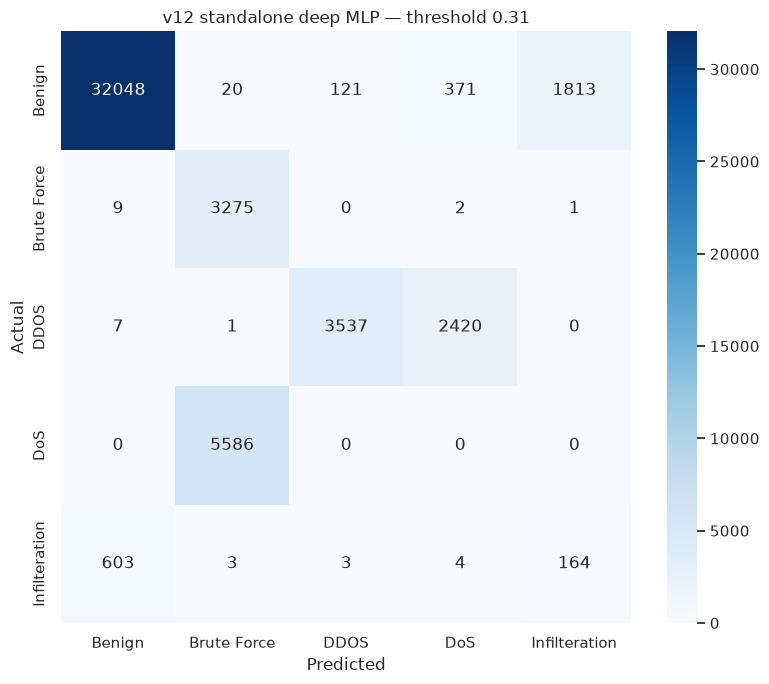

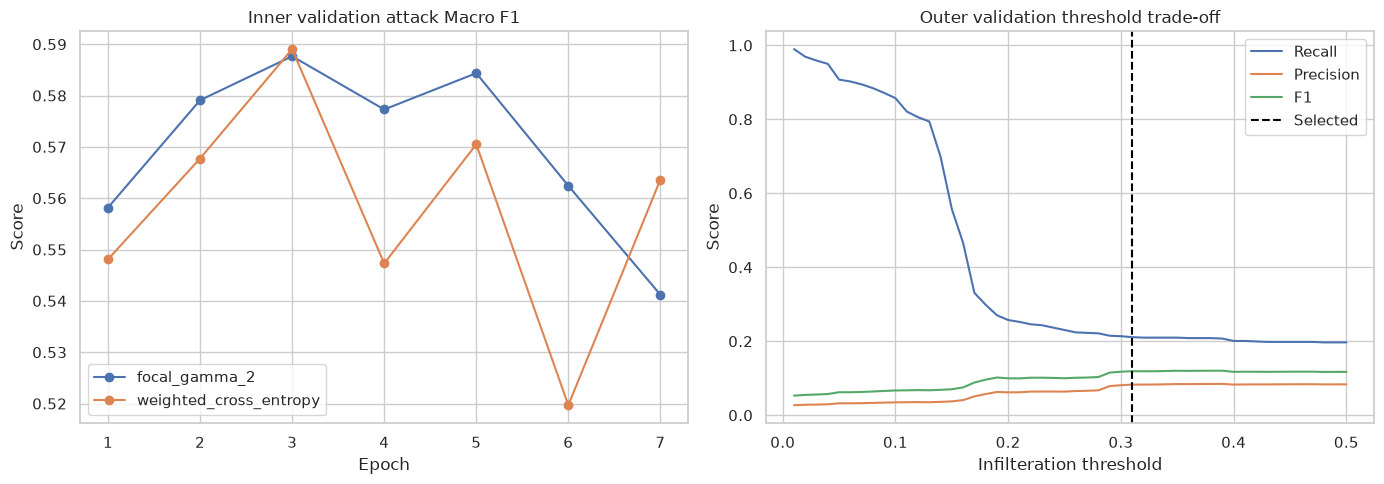

,model,weighted_f1_attacks,macro_f1_attacks,accuracy,infilteration_precision,infilteration_recall,infilteration_f1,benign_to_infilteration_fp,bruteforce_f1,ddos_f1,dos_f1,bruteforce_precision,bruteforce_recall,ddos_precision,ddos_recall,dos_precision,dos_recall
0,v11_champion,0.920264,0.754209,0.901856,0.091271,0.501931,0.154455,3883,0.920461,0.994183,0.947735,NaN,NaN,NaN,NaN,NaN,NaN
1,v12_standalone_deep_mlp,0.399929,0.348015,0.780667,0.082912,0.211068,0.119056,1813,0.538120,0.734885,0.000000,0.368599,0.996349,0.966129,0.592959,0.0,0.0


,check,passed
0,full_recall_at_least_0_55,False
1,full_precision_at_least_0_08,True
2,full_f1_better_than_v11,False
3,full_accuracy_at_least_0_90,False
4,full_false_positives_at_most_4000,True
5,attack_weighted_f1_at_least_0_90,False
6,late_recall_better_than_v11,False
7,late_f1_better_than_v11,False


Hypothesis supported: False


In [7]:
promotion_checks = {
    "full_recall_at_least_0_55": selected_metrics["infilteration_recall"] >= 0.55,
    "full_precision_at_least_0_08": selected_metrics["infilteration_precision"] >= 0.08,
    "full_f1_better_than_v11": selected_metrics["infilteration_f1"] > V11_BASELINE["infilteration_f1"],
    "full_accuracy_at_least_0_90": selected_metrics["accuracy"] >= 0.90,
    "full_false_positives_at_most_4000": selected_metrics["benign_to_infilteration_fp"] <= 4000,
    "attack_weighted_f1_at_least_0_90": selected_metrics["weighted_f1_attacks"] >= 0.90,
    "late_recall_better_than_v11": late_metrics["infilteration_recall"] > V11_LATE["infilteration_recall"],
    "late_f1_better_than_v11": late_metrics["infilteration_f1"] > V11_LATE["infilteration_f1"],
}
hypothesis_supported = all(promotion_checks.values())

summary_df = pd.DataFrame([
    {"model": "v11_champion", **V11_BASELINE},
    {"model": "v12_standalone_deep_mlp", **selected_metrics},
])
summary_path = OUTPUT_DIR / "v12_champion_summary.csv"
summary_df.to_csv(summary_path, index=False, encoding="utf-8-sig")
late_path = OUTPUT_DIR / "v12_late_holdout_summary.csv"
pd.DataFrame([late_metrics]).to_csv(late_path, index=False, encoding="utf-8-sig")
checks_path = OUTPUT_DIR / "v12_promotion_checks.csv"
pd.DataFrame({"check": promotion_checks.keys(), "passed": promotion_checks.values()}).to_csv(
    checks_path, index=False, encoding="utf-8-sig"
)

report_path = OUTPUT_DIR / "v12_classification_report.csv"
pd.DataFrame(classification_report(
    y_outer_valid, selected_prediction, labels=classes, output_dict=True, zero_division=0
)).T.to_csv(report_path, encoding="utf-8-sig")

cm = confusion_matrix(y_outer_valid, selected_prediction, labels=classes)
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes, ax=ax)
ax.set(title=f"v12 standalone deep MLP — threshold {selected_threshold:g}", xlabel="Predicted", ylabel="Actual")
plt.tight_layout()
cm_path = OUTPUT_DIR / "v12_confusion_matrix.png"
fig.savefig(cm_path, dpi=140, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, group in history_df.groupby("candidate"):
    axes[0].plot(group["epoch"], group["macro_f1_attacks"], marker="o", label=name)
axes[0].set(title="Inner validation attack Macro F1", xlabel="Epoch", ylabel="Score")
axes[0].legend()
axes[1].plot(search_df["infilteration_threshold"], search_df["infilteration_recall"], label="Recall")
axes[1].plot(search_df["infilteration_threshold"], search_df["infilteration_precision"], label="Precision")
axes[1].plot(search_df["infilteration_threshold"], search_df["infilteration_f1"], label="F1")
axes[1].axvline(selected_threshold, color="black", linestyle="--", label="Selected")
axes[1].set(title="Outer validation threshold trade-off", xlabel="Infilteration threshold", ylabel="Score")
axes[1].legend()
plt.tight_layout()
tradeoff_path = OUTPUT_DIR / "v12_training_threshold_tradeoff.png"
fig.savefig(tradeoff_path, dpi=140, bbox_inches="tight")
plt.show()

display(summary_df)
display(pd.DataFrame({"check": promotion_checks.keys(), "passed": promotion_checks.values()}))
print("Hypothesis supported:", hypothesis_supported)


## 7. MLflow 실제 검증 Run과 독립 딥러닝 모델 기록


In [8]:
notebook_path = cwd / "code_mlflow_pipeline_v12.ipynb"
code_version = file_sha256(notebook_path) if notebook_path.exists() else "unavailable"
input_example = X_all.loc[outer_valid_index, feature_columns].iloc[:5].copy()
candidate_model = DeepIDSPyFuncModel(
    final_network, outer_preprocessor, classes,
    infilteration_threshold=selected_threshold,
)
output_example = candidate_model.predict(None, input_example)
signature = infer_signature(input_example, output_example)
lineage_sample = train_df.iloc[:2000].copy()
lineage_numeric = lineage_sample.select_dtypes(include=[np.number]).columns
lineage_sample[lineage_numeric] = lineage_sample[lineage_numeric].astype(float)

with hypothesis_run(
    run_name="v12_standalone_deep_mlp_validation",
    hypothesis_id=HYPOTHESIS_ID,
    hypothesis=HYPOTHESIS,
    stage="chronological_validation",
    promotion_status="candidate" if hypothesis_supported else "rejected",
    validation_strategy="nested_time_validation_plus_late_half_holdout",
    notebook=notebook_path.name,
    data_version=TRAIN_PARQUET.name,
    feature_schema_version="raw-flow-40-v1",
    code_version=code_version,
    extra_tags={
        "champion_remains": "v12" if hypothesis_supported else "v11",
        "model_family": "pytorch_residual_mlp",
        "standalone_from_prior_models": "true",
        "validation_cohort_id": VALIDATION_COHORT_ID,
        "strictly_comparable": "true",
    },
) as parent_run:
    mlflow.log_params({
        "selected_loss": selected_name,
        "focal_gamma": selected_candidate["gamma"],
        "selected_epochs": selected_candidate["best_epoch"],
        "infilteration_threshold": selected_threshold,
        "selection_tier": selection_tier,
        "width": WIDTH, "blocks": BLOCKS, "dropout": DROPOUT,
        "batch_size": BATCH_SIZE, "learning_rate": LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY, "torch_version": torch.__version__,
        "device": "cpu", "raw_feature_count": len(feature_columns),
        "train_sample": TRAIN_SAMPLE, "random_state": RANDOM_STATE,
        "training_data_sha256": file_sha256(TRAIN_PARQUET),
    })
    logged_metrics = {**selected_metrics}
    logged_metrics.update({f"late_holdout_{key}": float(value) for key, value in late_metrics.items()})
    logged_metrics.update({f"delta_vs_v11_{key}": float(selected_metrics[key] - V11_BASELINE[key]) for key in [
        "accuracy", "weighted_f1_attacks", "macro_f1_attacks",
        "infilteration_precision", "infilteration_recall", "infilteration_f1",
        "benign_to_infilteration_fp",
    ]})
    logged_metrics["candidate_training_seconds"] = float(sum(candidate["train_seconds"] for candidate in candidates))
    logged_metrics["refit_seconds"] = float(refit_seconds)
    mlflow.log_metrics({key: float(value) for key, value in logged_metrics.items()})
    log_dataframe_input(
        lineage_sample, source=TRAIN_PARQUET,
        name="raw_train_reservoir_lineage_sample", context="standalone_deep_training", targets=TARGET,
    )
    for artifact in [candidate_path, history_path, search_path, summary_path, late_path, checks_path, report_path, cm_path, tradeoff_path]:
        mlflow.log_artifact(str(artifact))
    mlflow.log_artifact(str(notebook_path), artifact_path="code")
    for candidate in candidates:
        with mlflow.start_run(run_name=f"v12_candidate_{candidate['name']}", nested=True):
            mlflow.set_tags({
                "hypothesis_id": HYPOTHESIS_ID,
                "stage": "inner_validation_candidate",
                "model_family": "pytorch_residual_mlp",
            })
            mlflow.log_params({
                "loss": candidate["name"], "focal_gamma": candidate["gamma"],
                "best_epoch": candidate["best_epoch"], "width": WIDTH,
                "blocks": BLOCKS, "dropout": DROPOUT,
            })
            mlflow.log_metrics({
                **{key: float(value) for key, value in candidate["best_metrics"].items()},
                "train_seconds": float(candidate["train_seconds"]),
            })
    model_info = mlflow.pyfunc.log_model(
        name="candidate_network_classifier",
        python_model=candidate_model,
        input_example=input_example,
        signature=signature,
        code_paths=[str(PROJECT_DIR / "src" / "deep_ids_model.py")],
        pip_requirements=[
            f"mlflow=={importlib.metadata.version('mlflow')}",
            f"torch=={importlib.metadata.version('torch')}",
            f"numpy=={importlib.metadata.version('numpy')}",
            f"pandas=={importlib.metadata.version('pandas')}",
        ],
        metadata={
            "model_family": "standalone_raw_flow_residual_mlp",
            "infilteration_threshold": selected_threshold,
            "validation_cohort_id": VALIDATION_COHORT_ID,
        },
    )
    validation_run_id = parent_run.info.run_id
    candidate_model_uri = model_info.model_uri

print("Validation run:", validation_run_id)
print("Candidate model:", candidate_model_uri)


🏃 View run v12_candidate_weighted_cross_entropy at: http://mlflow:5000/#/experiments/1/runs/2972949f910f49a9a7c063f733236e94
🧪 View experiment at: http://mlflow:5000/#/experiments/1


🏃 View run v12_candidate_focal_gamma_2 at: http://mlflow:5000/#/experiments/1/runs/fd664ba84dad430abf0772ac223766f9
🧪 View experiment at: http://mlflow:5000/#/experiments/1


2026/08/17 13:42:11 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code during deserialization.Consider using a file path (str or Path) instead. See https://mlflow.org/docs/latest/ml/model/models-from-code/ for details.


2026/08/17 13:42:11 INFO mlflow.pyfunc: Validating input example against model signature


🏃 View run v12_standalone_deep_mlp_validation at: http://mlflow:5000/#/experiments/1/runs/b75e91ee9efc4d63a461b3ec49c7d528
🧪 View experiment at: http://mlflow:5000/#/experiments/1
Validation run: b75e91ee9efc4d63a461b3ec49c7d528
Candidate model: models:/m-d47e70b55af84c8eb86a359b1aee11d6


## 8. 조건부 전체 재학습·Registry 승격


In [9]:
final_run_id = None
registry_version = None
submission_path = None

if hypothesis_supported:
    full_preprocessor = DeepIDSPreprocessor.fit(X_all, categorical_columns=CAT_FEATURES)
    full_network, full_history, full_seconds = fit_fixed_epochs(
        selected_candidate["gamma"], full_preprocessor, train_df.index,
        selected_candidate["best_epoch"],
    )
    deployable = DeepIDSPyFuncModel(
        full_network, full_preprocessor, classes,
        infilteration_threshold=selected_threshold,
    )
    final_input_example = X_all.iloc[:5].copy()
    final_output_example = deployable.predict(None, final_input_example)
    final_signature = infer_signature(final_input_example, final_output_example)
    with hypothesis_run(
        run_name="v12_standalone_deep_mlp_refit",
        hypothesis_id=HYPOTHESIS_ID, hypothesis=HYPOTHESIS,
        stage="refit", promotion_status="champion",
        validation_strategy="approved_v12_nested_time_validation",
        notebook=notebook_path.name, data_version=TRAIN_PARQUET.name,
        feature_schema_version="raw-flow-40-v1",
        code_version=file_sha256(notebook_path),
        extra_tags={
            "source_validation_run_id": validation_run_id,
            "model_family": "pytorch_residual_mlp",
            "standalone_from_prior_models": "true",
        },
    ) as final_run:
        mlflow.log_params({
            "source_validation_run_id": validation_run_id,
            "epochs": selected_candidate["best_epoch"],
            "loss": selected_name,
            "infilteration_threshold": selected_threshold,
        })
        mlflow.log_metrics({**{key: float(value) for key, value in selected_metrics.items()}, "refit_seconds": full_seconds})
        log_dataframe_input(
            lineage_sample, source=TRAIN_PARQUET,
            name="raw_train_reservoir_lineage_sample", context="approved_full_refit", targets=TARGET,
        )
        final_info = mlflow.pyfunc.log_model(
            name="network_classifier", python_model=deployable,
            input_example=final_input_example, signature=final_signature,
            code_paths=[str(PROJECT_DIR / "src" / "deep_ids_model.py")],
            pip_requirements=[
                f"mlflow=={importlib.metadata.version('mlflow')}",
                f"torch=={importlib.metadata.version('torch')}",
                f"numpy=={importlib.metadata.version('numpy')}",
                f"pandas=={importlib.metadata.version('pandas')}",
            ],
        )
        version = register_model_version(
            model_uri=final_info.model_uri,
            version_tags={
                "validation_status": "passed", "hypothesis_id": HYPOTHESIS_ID,
                "source_validation_run_id": validation_run_id,
                "model_family": "pytorch_residual_mlp",
            },
            registered_model_tags={
                "project": "network-classification",
                "task": "multiclass-classification",
                "architecture": "standalone_pytorch_residual_mlp",
            },
        )
        final_run_id = final_run.info.run_id
        registry_version = version.version

    with duckdb.connect() as connection:
        test_df = connection.execute(f"SELECT * FROM {parquet_expr(TEST_PARQUET)}").df()
    test_ids = test_df[ID_COL].copy()
    X_test = test_df.loc[:, feature_columns].copy()
    for column in CAT_FEATURES:
        X_test[column] = X_test[column].astype("string")
    test_prediction = deployable.predict(None, X_test)[TARGET].to_numpy()
    submission = pd.DataFrame({ID_COL: test_ids, TARGET: test_prediction}).set_index(ID_COL)
    submission_path = OUTPUT_DIR / "submission_v12.csv"
    submission.to_csv(submission_path, encoding="utf-8-sig")
    status_path = OUTPUT_DIR / "APPROVED.md"
else:
    failed = [name for name, passed in promotion_checks.items() if not passed]
    status_path = OUTPUT_DIR / "REJECTED.md"

status_path.write_text(
    f"# v12 experiment status: {'approved' if hypothesis_supported else 'rejected'}\n\n"
    f"- Standalone model: raw-flow residual MLP\n"
    f"- Selected loss / epochs: {selected_name} / {selected_candidate['best_epoch']}\n"
    f"- Infilteration threshold: {selected_threshold}\n"
    f"- Precision / Recall / F1: {selected_metrics['infilteration_precision']:.6f} / {selected_metrics['infilteration_recall']:.6f} / {selected_metrics['infilteration_f1']:.6f}\n"
    f"- Accuracy: {selected_metrics['accuracy']:.6f}; false positives: {int(selected_metrics['benign_to_infilteration_fp'])}\n"
    f"- Failed checks: {', '.join(failed) if not hypothesis_supported else 'none'}\n"
    f"- Validation run: `{validation_run_id}`\n"
    f"- Candidate model: `{candidate_model_uri}`\n",
    encoding="utf-8",
)

print("Status          :", "approved" if hypothesis_supported else "rejected")
print("Status file     :", status_path)
print("Final run       :", final_run_id)
print("Registry version:", registry_version)
print("Submission      :", submission_path)


Status          : rejected
Status file     : /home/jovyan/work/network-classification/outputs/v12/REJECTED.md
Final run       : None
Registry version: None
Submission      : None
